# Phase 2 — Exploratory Data Analysis (EDA)

**Objective:** Explore class imbalance, transaction amount and time distributions, feature relationships with fraud, and duplicate records to identify important patterns before preprocessing and model training.

**Key Focus:**
- Analyze legitimate vs fraud distribution
- Understand transaction amount and time patterns
- Identify features associated with fraud
- Compare legitimate and fraudulent transactions
- Detect duplicate records and label conflicts

**Outcome:** The dataset is highly imbalanced, transaction amounts are right-skewed, fraud shows different feature distributions, and duplicate records contain no conflicting labels.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("creditCardfraud/data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


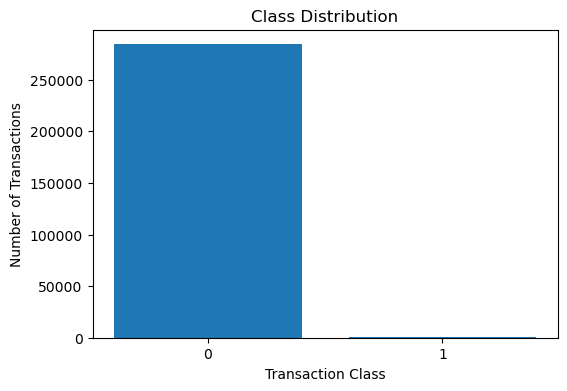

In [2]:
class_counts = df["Class"].value_counts()
print(class_counts)

plt.figure(figsize=(6,4))

plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")

plt.show()


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


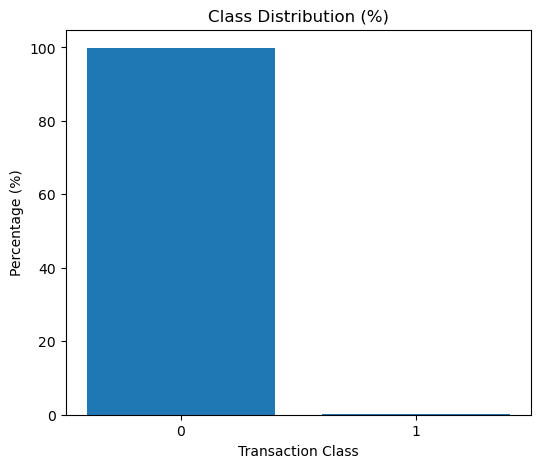

In [3]:
class_percentage = df["Class"].value_counts(normalize=True)*100

print(class_percentage)

plt.figure(figsize=(6,5))

plt.bar(
    class_percentage.index.astype(str),
    class_percentage.values
)

plt.xlabel("Transaction Class")
plt.ylabel("Percentage (%)")
plt.title("Class Distribution (%)")
plt.show()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


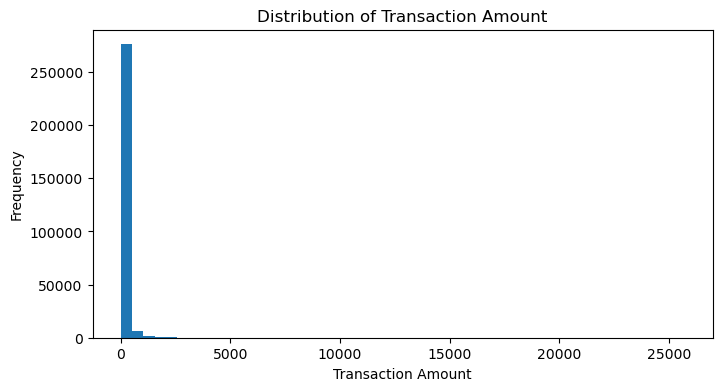

In [4]:
print(df["Amount"].describe())

plt.figure(figsize=(8,4))

plt.hist(df["Amount"],bins=50)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")

plt.show()

In [5]:
legitimate_amount = df.loc[df["Class"]==0,"Amount"]
fraud_amount = df.loc[df["Class"]==1,"Amount"]

print("Legitimate_amount: ")
print(legitimate_amount.describe())

print("Fraud_amount: ")
print(fraud_amount.describe())

Legitimate_amount: 
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
Fraud_amount: 
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


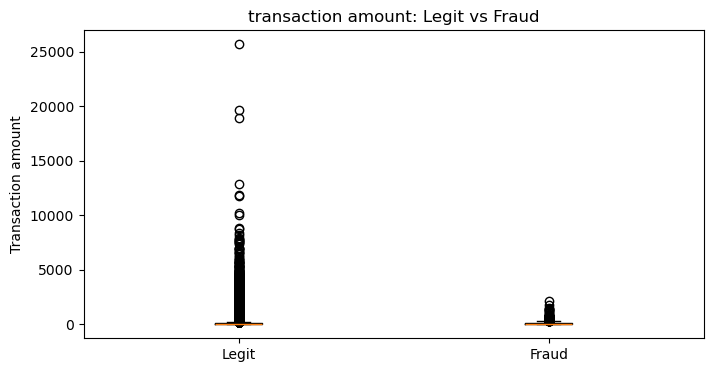

In [6]:
plt.figure(figsize=(8,4))
plt.boxplot([legitimate_amount,fraud_amount],labels=["Legit","Fraud"])
plt.ylabel("Transaction amount")
plt.title("transaction amount: Legit vs Fraud")
plt.show()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


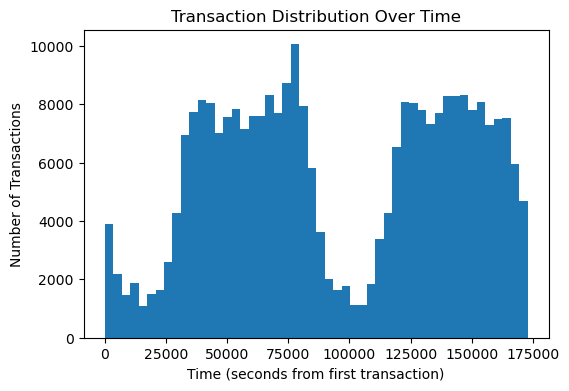

In [7]:
print(df["Time"].describe())

plt.figure(figsize=(6,4))

plt.hist(df["Time"],bins=50)

plt.xlabel("Time (seconds from first transaction)")
plt.ylabel("Number of Transactions")
plt.title("Transaction Distribution Over Time")
plt.show()

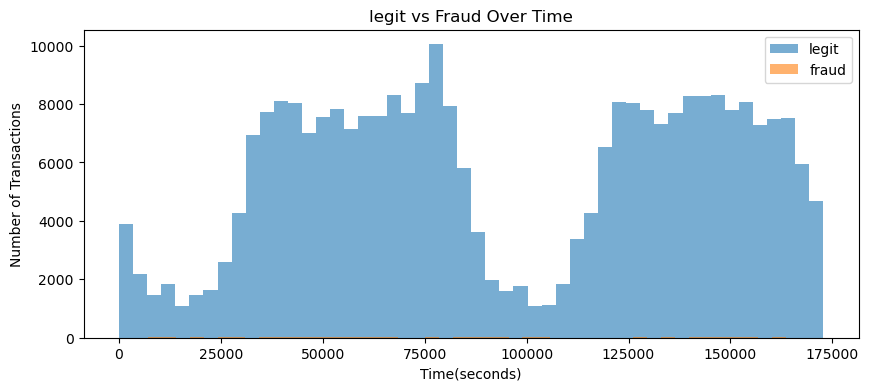

In [8]:
legit_time = df.loc[df["Class"]==0,"Time"]
fraud_time = df.loc[df["Class"]==1,"Time"]

plt.figure(figsize=(10,4))

plt.hist(
    legit_time,bins=50,alpha=0.6,label="legit",
)

plt.hist(
    fraud_time,bins=50,alpha=0.6,label="fraud",
)

plt.xlabel("Time(seconds)")
plt.ylabel("Number of Transactions")
plt.title("legit vs Fraud Over Time")
plt.legend()
plt.show()

In [9]:
v_features = [f"V{i}" for i in range(1,29)]

v_stats = df[v_features].describe().T

v_stats[["mean","std","min","max"]]

,mean,std,min,max
V1,1.168375e-15,1.958696,-56.407510,2.454930
V2,3.416908e-16,1.651309,-72.715728,22.057729
V3,-1.379537e-15,1.516255,-48.325589,9.382558
V4,2.074095e-15,1.415869,-5.683171,16.875344
V5,9.604066e-16,1.380247,-113.743307,34.801666
V6,1.487313e-15,1.332271,-26.160506,73.301626
V7,-5.556467e-16,1.237094,-43.557242,120.589494
V8,1.213481e-16,1.194353,-73.216718,20.007208
V9,-2.406331e-15,1.098632,-13.434066,15.594995
V10,2.239053e-15,1.088850,-24.588262,23.745136


In [10]:
correlation_with_class = df.corr(numeric_only=True)["Class"]

correlation_with_class = correlation_with_class.sort_values(ascending=False)
print(correlation_with_class)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [11]:
feature_correlation = correlation_with_class.drop("Class")

strongest_features = (
    feature_correlation
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print(strongest_features)

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


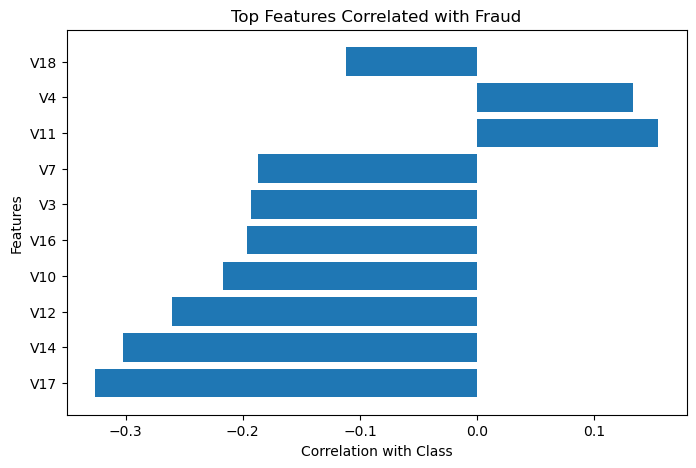

In [12]:
top_features = strongest_features.index

plt.figure(figsize=(8,5))

plt.barh(top_features,feature_correlation[top_features])

plt.xlabel("Correlation with Class")
plt.ylabel('Features')
plt.title("Top Features Correlated with Fraud")

plt.show()

In [13]:
feature = strongest_features.index[0]

print("Feature selected: ",feature)

legitimate_feature = df.loc[df["Class"] == 0,feature]
fraud_feature = df.loc[df["Class"] == 1,feature]

print("\nLegitimate:")
print(legitimate_feature.describe())

print("\nFraud:")
print(fraud_feature.describe())

Feature selected:  V17

Legitimate:
count    284315.000000
mean          0.011535
std           0.749457
min         -17.098444
25%          -0.482644
50%          -0.064833
75%           0.399922
max           9.253526
Name: V17, dtype: float64

Fraud:
count    492.000000
mean      -6.665836
std        6.970618
min      -25.162799
25%      -11.945057
50%       -5.302949
75%       -1.341940
max        6.739384
Name: V17, dtype: float64


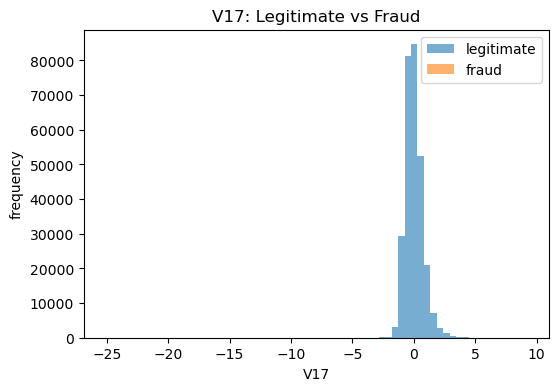

In [14]:
plt.figure(figsize=(6,4))

plt.hist(legitimate_feature,bins=50,alpha=0.6,label="legitimate")

plt.hist(fraud_feature,bins=50,alpha=0.6,label="fraud")

plt.xlabel(feature)

plt.ylabel("frequency")

plt.title(f"{feature}: Legitimate vs Fraud")
plt.legend()
plt.show()

In [15]:
duplicates = df[df.duplicated(keep=False)]

print("Rows involved in duplicate groups: ",len(duplicates))

duplicates.head(10)

Rows involved in duplicate groups:  1854


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [16]:
feature_columns = df.columns.drop("Class")

duplicate_label_conflicts =(duplicates.groupby(list(feature_columns))["Class"].nunique())

conflicting_duplicates = duplicate_label_conflicts[duplicate_label_conflicts > 1]

print("Duplicate groups with conflicting labels: ",len(conflicting_duplicates))



Duplicate groups with conflicting labels:  0
